In [1]:
path_to_file="D:/Profils/NLefort/Desktop/introduction_to_python_for_data_science/pandas_trianing"

import pandas as pd

data=pd.read_csv(path_to_file+"/covid-19.csv")

data=data.iloc[:,1:]
data.head()


,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp
0,2020-04-23,23,4,2020,933,264,Belgium,BE,BEL,11422068.0,Europe
1,2020-04-22,22,4,2020,973,170,Belgium,BE,BEL,11422068.0,Europe
2,2020-04-21,21,4,2020,1487,145,Belgium,BE,BEL,11422068.0,Europe
3,2020-04-20,20,4,2020,1313,230,Belgium,BE,BEL,11422068.0,Europe
4,2020-04-19,19,4,2020,1045,290,Belgium,BE,BEL,11422068.0,Europe


In [2]:
#on va se focaliser sur les US
#je crée mon masque
mask=data["geoId"] == "US"
#je stocke mon masque dans une nouvelle variable
us_data=data[mask]
#j'affiche les valeurs
us_data.head()



,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp
575,2020-04-23,23,4,2020,17588,1721,United_States_of_America,US,USA,327167434.0,America
576,2020-04-22,22,4,2020,37289,2524,United_States_of_America,US,USA,327167434.0,America
577,2020-04-21,21,4,2020,28065,1857,United_States_of_America,US,USA,327167434.0,America
578,2020-04-20,20,4,2020,24601,1772,United_States_of_America,US,USA,327167434.0,America
579,2020-04-19,19,4,2020,32922,1856,United_States_of_America,US,USA,327167434.0,America


In [3]:
#je veux cependant qu'au lieu de commencer à la ligne 575, on commence à 0
#pour cela on fait reset index
#si on fait juste --> us_data.reset_index on ajoute une colonne index, mais l'ancienne reste toujours

us_data=us_data.reset_index(drop=True)
us_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp
0,2020-04-23,23,4,2020,17588,1721,United_States_of_America,US,USA,327167434.0,America
1,2020-04-22,22,4,2020,37289,2524,United_States_of_America,US,USA,327167434.0,America
2,2020-04-21,21,4,2020,28065,1857,United_States_of_America,US,USA,327167434.0,America
3,2020-04-20,20,4,2020,24601,1772,United_States_of_America,US,USA,327167434.0,America
4,2020-04-19,19,4,2020,32922,1856,United_States_of_America,US,USA,327167434.0,America


In [4]:
#on ajoute une nouvelle clé "cumulated cases"
us_data["cumulated_cases"] = 0
us_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp,cumulated_cases
0,2020-04-23,23,4,2020,17588,1721,United_States_of_America,US,USA,327167434.0,America,0
1,2020-04-22,22,4,2020,37289,2524,United_States_of_America,US,USA,327167434.0,America,0
2,2020-04-21,21,4,2020,28065,1857,United_States_of_America,US,USA,327167434.0,America,0
3,2020-04-20,20,4,2020,24601,1772,United_States_of_America,US,USA,327167434.0,America,0
4,2020-04-19,19,4,2020,32922,1856,United_States_of_America,US,USA,327167434.0,America,0


In [5]:
#calculer le dernier index de notre BDD
#on doit d'abord savoir la longueur de notre liste
len(us_data)


115

In [6]:
#j'ai 115 lignes, que je stocke dans une variable
total_rows=len(us_data)
print(total_rows)

115


In [7]:
us_data.tail()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp,cumulated_cases
110,2020-01-04,4,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0
111,2020-01-03,3,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0
112,2020-01-02,2,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0
113,2020-01-01,1,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0
114,2019-12-31,31,12,2019,0,0,United_States_of_America,US,USA,327167434.0,America,0


In [8]:
#rappelons nous que la première valeur de mon index = 0. c'est donc normal que la fin de mon index = 114

In [9]:
#je fais une boucle
#pour chaque répétition dans mon jeu de données, je pars de total lignes, je vais jusqu'à -1 et chaque niveau -1
#je dois nénamoins partir de -2 car 114+1 = 115 ce qui est bien le total de ma série, mais je pars de i+1 qui ferai 116 et donc ne serai pas dans mon intervalle
for i in range(total_rows -2,-1,-1):
#to get the cumulated cases, all the cases de la dernière ligne + cases de la ligne du jour précédent
    us_data.loc[i,"cumulated_cases"]=us_data.loc[i, "cases"]+us_data.loc[i+1,"cumulated_cases"]

In [10]:
us_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp,cumulated_cases
0,2020-04-23,23,4,2020,17588,1721,United_States_of_America,US,USA,327167434.0,America,842629
1,2020-04-22,22,4,2020,37289,2524,United_States_of_America,US,USA,327167434.0,America,825041
2,2020-04-21,21,4,2020,28065,1857,United_States_of_America,US,USA,327167434.0,America,787752
3,2020-04-20,20,4,2020,24601,1772,United_States_of_America,US,USA,327167434.0,America,759687
4,2020-04-19,19,4,2020,32922,1856,United_States_of_America,US,USA,327167434.0,America,735086


In [11]:
#je veux savoir au-delà des cas cumulés, combien il y a de nouveaux cas par jour
us_data["new_cases"]=0
for i in range(total_rows -2, -1, -1):
    us_data.loc[i,"new_cases"]=us_data.loc[i, "cumulated_cases"]-us_data.loc[i+1,"cumulated_cases"]

In [12]:
us_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp,cumulated_cases,new_cases
0,2020-04-23,23,4,2020,17588,1721,United_States_of_America,US,USA,327167434.0,America,842629,17588
1,2020-04-22,22,4,2020,37289,2524,United_States_of_America,US,USA,327167434.0,America,825041,37289
2,2020-04-21,21,4,2020,28065,1857,United_States_of_America,US,USA,327167434.0,America,787752,28065
3,2020-04-20,20,4,2020,24601,1772,United_States_of_America,US,USA,327167434.0,America,759687,24601
4,2020-04-19,19,4,2020,32922,1856,United_States_of_America,US,USA,327167434.0,America,735086,32922


In [13]:
#ratio de croissance
#nouveaux cas du jour/cas du jour précédent
us_data["growth_ratio"]=0
for i in range(total_rows -2, -1, -1):
    us_data.loc[i,"growth_ratio"]=us_data.loc[i, "new_cases"]/us_data.loc[i+1,"new_cases"]

us_data.head()

C:\Users\NLefort\AppData\Local\Temp\ipykernel_26500\92229694.py:5: RuntimeWarning: invalid value encountered in scalar divide
  us_data.loc[i,"growth_ratio"]=us_data.loc[i, "new_cases"]/us_data.loc[i+1,"new_cases"]
C:\Users\NLefort\AppData\Local\Temp\ipykernel_26500\92229694.py:5: RuntimeWarning: invalid value encountered in scalar divide
  us_data.loc[i,"growth_ratio"]=us_data.loc[i, "new_cases"]/us_data.loc[i+1,"new_cases"]
C:\Users\NLefort\AppData\Local\Temp\ipykernel_26500\92229694.py:5: RuntimeWarning: invalid value encountered in scalar divide
  us_data.loc[i,"growth_ratio"]=us_data.loc[i, "new_cases"]/us_data.loc[i+1,"new_cases"]
C:\Users\NLefort\AppData\Local\Temp\ipykernel_26500\92229694.py:5: RuntimeWarning: invalid value encountered in scalar divide
  us_data.loc[i,"growth_ratio"]=us_data.loc[i, "new_cases"]/us_data.loc[i+1,"new_cases"]
C:\Users\NLefort\AppData\Local\Temp\ipykernel_26500\92229694.py:5: RuntimeWarning: invalid value encountered in scalar divide
  us_data.loc[

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp,cumulated_cases,new_cases,growth_ratio
0,2020-04-23,23,4,2020,17588,1721,United_States_of_America,US,USA,327167434.0,America,842629,17588,0.471667
1,2020-04-22,22,4,2020,37289,2524,United_States_of_America,US,USA,327167434.0,America,825041,37289,1.328666
2,2020-04-21,21,4,2020,28065,1857,United_States_of_America,US,USA,327167434.0,America,787752,28065,1.140807
3,2020-04-20,20,4,2020,24601,1772,United_States_of_America,US,USA,327167434.0,America,759687,24601,0.747251
4,2020-04-19,19,4,2020,32922,1856,United_States_of_America,US,USA,327167434.0,America,735086,32922,1.067752


Matplotlib is building the font cache; this may take a moment.


<Axes: xlabel='dateRep'>

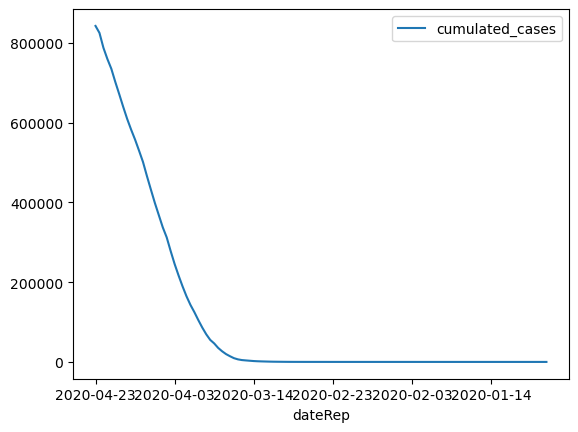

In [14]:
#see the number of cumulated cases per day
us_data.plot.line(x="dateRep", y="cumulated_cases")

In [15]:
#on est pas à l'endroit dans les dates. on doit le lire dans l'autre sens
us_data=us_data.sort_values("dateRep")
us_data.head()

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,continentExp,cumulated_cases,new_cases,growth_ratio
114,2019-12-31,31,12,2019,0,0,United_States_of_America,US,USA,327167434.0,America,0,0,0.0
113,2020-01-01,1,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0,0,NaN
112,2020-01-02,2,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0,0,NaN
111,2020-01-03,3,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0,0,NaN
110,2020-01-04,4,1,2020,0,0,United_States_of_America,US,USA,327167434.0,America,0,0,NaN


<Axes: xlabel='dateRep'>

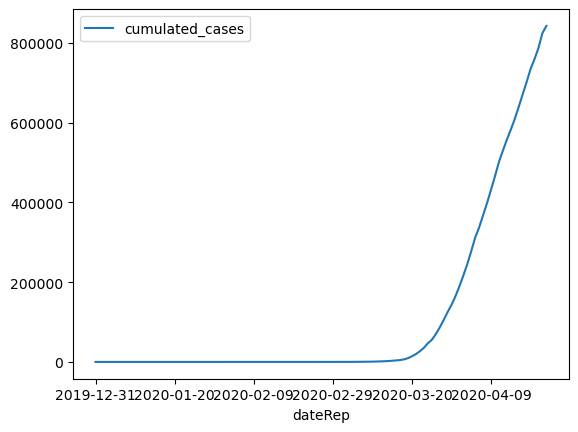

In [16]:
us_data.plot.line(x="dateRep", y="cumulated_cases")

<Axes: xlabel='dateRep'>

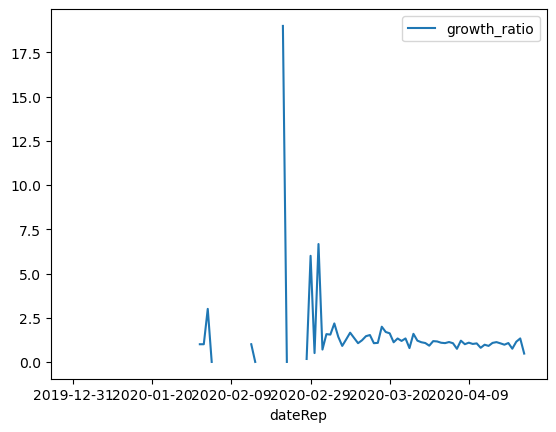

In [17]:
us_data.plot.line(x="dateRep", y="growth_ratio")

<Axes: xlabel='dateRep'>

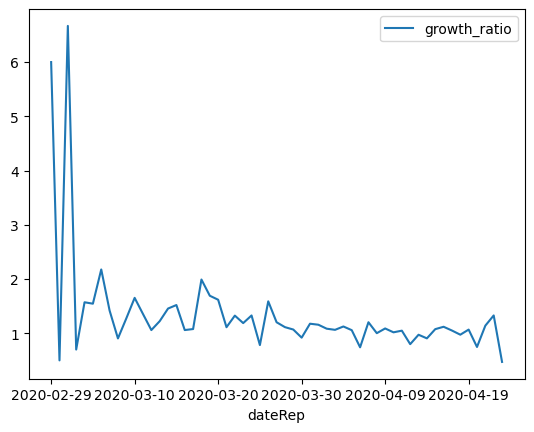

In [18]:
#on va avoir besoin de filtrer pour rendre cela lisible
mask=us_data["dateRep"]>="2020-02-29"
us_data[mask].plot.line(x="dateRep", y="growth_ratio")

<Axes: xlabel='dateRep'>

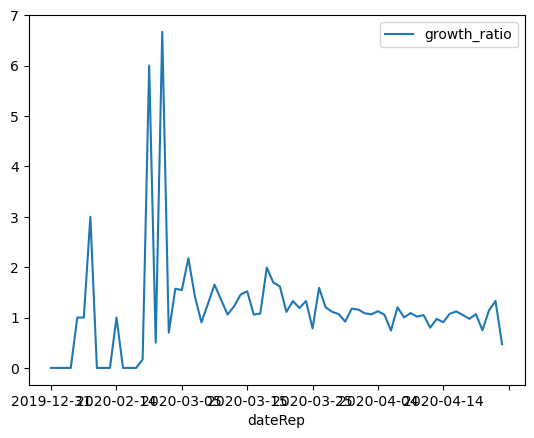

In [20]:
#ou on peut faire autrement
mask=us_data["growth_ratio"]<=7.5
us_data[mask].plot.line(x="dateRep", y="growth_ratio")

<Axes: xlabel='dateRep'>

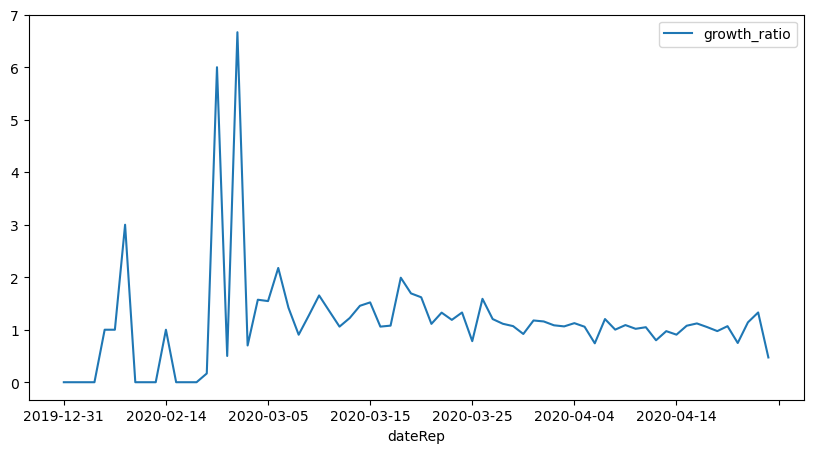

In [21]:
#on veut grossis le graph pour le rendre plus lisible
#ou on peut faire autrement
mask=us_data["growth_ratio"]<=7.5
us_data[mask].plot.line(x="dateRep", y="growth_ratio", figsize=(10,5))


<Axes: xlabel='dateRep'>

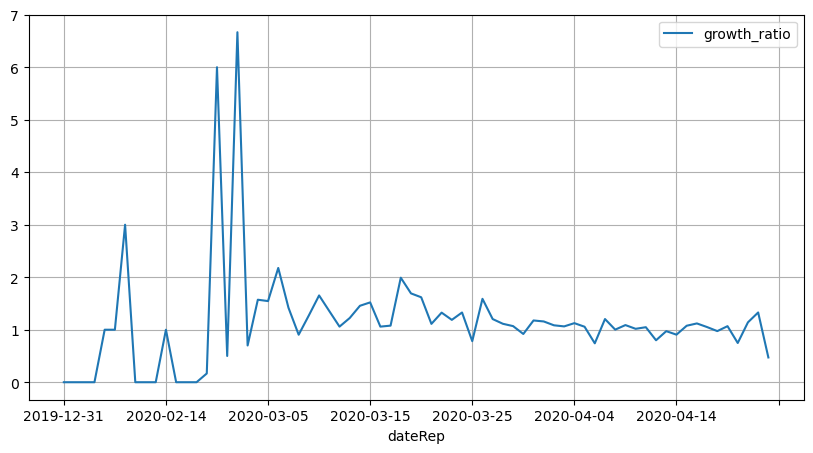

In [22]:
#utiliser une grille
#on veut grossis le graph pour le rendre plus lisible
#ou on peut faire autrement
mask=us_data["growth_ratio"]<=7.5
us_data[mask].plot.line(x="dateRep", y="growth_ratio", figsize=(10,5), grid=(True))


<Axes: xlabel='dateRep'>

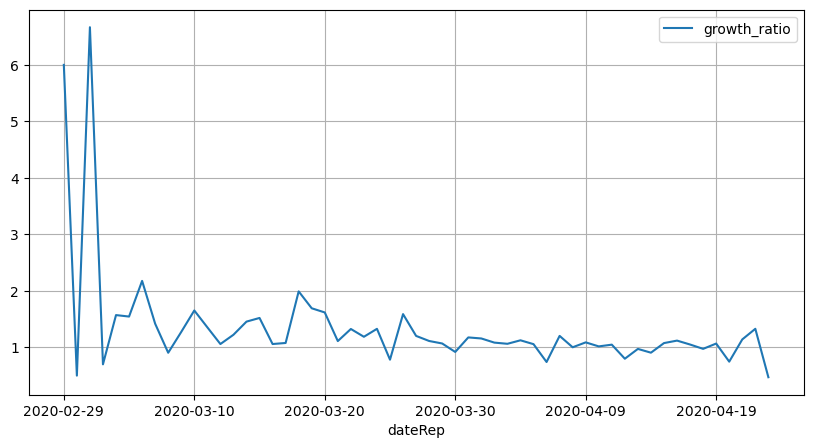

In [27]:
mask=us_data["dateRep"]>="2020-02-29"
us_data[mask].plot.line(x="dateRep", y="growth_ratio", figsize=(10,5),grid=(True))